In [114]:
from build.models.sub import *
from build import Genome
from build.util.datetime import eta, clock

import torch
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
# import matplotlib.
import numpy as np

In [115]:
torch.set_printoptions(threshold=10)

In [116]:
device = 'cuda'
dtype  = torch.float64

In [117]:
genomes = {key: Genome(key) for key in range(1, 2)}

In [118]:
batch_size  = 8
seq_len     = 32
input_dims  = 1
output_dims = 1
embedding   = 96
differential = False
heads       = 4

In [119]:
records = 100

In [120]:
upper   = 1000
divider = upper + seq_len

In [121]:
def create(genomes_num: int, low: int, high: int, records, seq_len: int, size: int, inv=True):
    inp = torch.stack([
        torch.stack([
            torch.arange(i, i+(size if not inv else seq_len)) for i in torch.randint(low, high, (seq_len if not inv else size,))
        ]) for _ in range(records)
    ])
    if inv:
        inp = inp.mT
    out = inp.clone() + 1
    return inp.to(device, dtype).unsqueeze(0).expand(genomes_num, *inp.shape) / divider, \
           out.to(device, dtype).unsqueeze(0).expand(genomes_num, *out.shape) / divider

In [122]:
train_inp, train_out = create(len(genomes), 0, upper, records, seq_len, output_dims, True)
eval_inp, eval_out   = create(len(genomes), 0, upper, records, seq_len, output_dims, True)

In [123]:
train_inp.shape, train_out.shape

(torch.Size([1, 100, 32, 1]), torch.Size([1, 100, 32, 1]))

In [124]:
train_inp.mT

tensor([[[[0.6628, 0.6638, 0.6647,  ..., 0.6909, 0.6919, 0.6928]],

         [[0.9564, 0.9574, 0.9583,  ..., 0.9845, 0.9855, 0.9864]],

         [[0.1579, 0.1589, 0.1599,  ..., 0.1860, 0.1870, 0.1880]],

         ...,

         [[0.0078, 0.0087, 0.0097,  ..., 0.0359, 0.0368, 0.0378]],

         [[0.9196, 0.9205, 0.9215,  ..., 0.9477, 0.9486, 0.9496]],

         [[0.7888, 0.7897, 0.7907,  ..., 0.8169, 0.8178, 0.8188]]]],
       device='cuda:0', dtype=torch.float64)

In [125]:
train_out.mT

tensor([[[[0.6638, 0.6647, 0.6657,  ..., 0.6919, 0.6928, 0.6938]],

         [[0.9574, 0.9583, 0.9593,  ..., 0.9855, 0.9864, 0.9874]],

         [[0.1589, 0.1599, 0.1609,  ..., 0.1870, 0.1880, 0.1890]],

         ...,

         [[0.0087, 0.0097, 0.0107,  ..., 0.0368, 0.0378, 0.0388]],

         [[0.9205, 0.9215, 0.9225,  ..., 0.9486, 0.9496, 0.9506]],

         [[0.7897, 0.7907, 0.7917,  ..., 0.8178, 0.8188, 0.8198]]]],
       device='cuda:0', dtype=torch.float64)

In [126]:
# test_inp = torch.randn(len(genomes), records, seq_len, output_dims, device=device)
# test_out = torch.cat([test_inp[..., 1:, :], torch.randn(len(genomes), records, 1, output_dims, device=device)], -2)

In [127]:
def model_size(model: NeatModule):
    return np.sum([param.numel() for param in model.parameters()])

In [128]:
constant = 2 ** np.floor(np.log2(seq_len * embedding)) // 2
constant

1024.0

In [129]:
attention = Attention(seq_len, embedding, heads, 1, constant=constant, causal_mask=True,
                      differential=differential, bias=True, device=device, dtype=dtype,
                      inputs=input_dims, outputs=output_dims)
optimizer = optim.AdamW(attention.parameters(), 1e-3)
attention.update(genomes)
attention, model_size(attention)

(Attention(
   (query_proj): Linear[NeatModule](inputs=1, outputs=96, bias=True)
   (key_proj): Linear[NeatModule](inputs=1, outputs=24, bias=True)
   (value_proj): Linear[NeatModule](inputs=1, outputs=24, bias=True)
   (out_proj): Linear[NeatModule](inputs=96, outputs=1, bias=True)
   (rotary_embedding): RoPE()
   (softmax): Softmax(dim=-1)
   (norm): RMSNorm[NeatModule](shape=(24,), eps=1e-08, elementwise_affine=True)
 ),
 409)

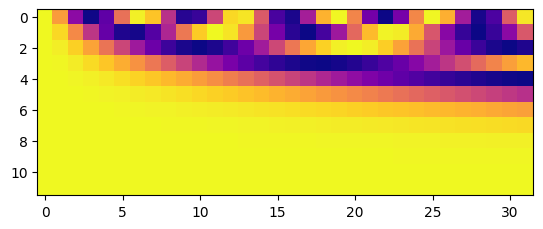

In [130]:
plt.imshow(attention.rotary_embedding.complex_frequencies[0, 0, ..., 0, :].cpu().float().mT, cmap='plasma')

In [131]:
# %%temit -r 10 -n 3
outputs, (att, att_val) = attention(eval_inp[:, :6], verbose=2, get=True)
att.max(), att.min()


Executing Self Attention
Post Linearization =>

Query =>
tensor([[[[-0.5269, -0.7659,  0.2123,  ...,  1.2102,  0.3327, -0.5804],
          [-0.5275, -0.7650,  0.2129,  ...,  1.2097,  0.3311, -0.5814],
          [-0.5280, -0.7642,  0.2136,  ...,  1.2093,  0.3295, -0.5824],
          ...,
          [-0.5429, -0.7418,  0.2317,  ...,  1.1974,  0.2863, -0.6094],
          [-0.5435, -0.7409,  0.2324,  ...,  1.1969,  0.2847, -0.6104],
          [-0.5440, -0.7401,  0.2331,  ...,  1.1965,  0.2831, -0.6114]],

         [[-0.9470, -0.1334,  0.7232,  ...,  0.8742, -0.8845, -1.3399],
          [-0.9476, -0.1326,  0.7239,  ...,  0.8738, -0.8861, -1.3409],
          [-0.9481, -0.1318,  0.7246,  ...,  0.8733, -0.8877, -1.3419],
          ...,
          [-0.9630, -0.1093,  0.7427,  ...,  0.8614, -0.9309, -1.3688],
          [-0.9636, -0.1085,  0.7434,  ...,  0.8610, -0.9325, -1.3698],
          [-0.9641, -0.1077,  0.7441,  ...,  0.8605, -0.9341, -1.3708]],

         [[-0.7792, -0.3861,  0.5191,  ..., 

(tensor(1., device='cuda:0', dtype=torch.float64),
 tensor(0., device='cuda:0', dtype=torch.float64))

In [132]:
outputs.shape

torch.Size([1, 6, 32, 1])

In [133]:
# torch.sum(torch.randn(1, 1, 4, 32, 1))

In [134]:
def normalize(tensor: Tensor):
    maximum, minimum = tensor.max(), tensor.min()
    if maximum-minimum != 0:
        return (tensor - minimum) / (maximum - minimum)
    else:
        return tensor

In [135]:
att.shape, att_val.shape

(torch.Size([1, 6, 4, 32, 32]), torch.Size([1, 6, 32, 96]))

In [136]:
for i, att_head in enumerate(eval_out[0, :3]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

Record 1: torch.Size([1, 32])
tensor([[201., 202., 203.,  ..., 230., 231., 232.]], device='cuda:0',
       dtype=torch.float64)
Record 2: torch.Size([1, 32])
tensor([[962., 963., 964.,  ..., 991., 992., 993.]], device='cuda:0',
       dtype=torch.float64)
Record 3: torch.Size([1, 32])
tensor([[658., 659., 660.,  ..., 687., 688., 689.]], device='cuda:0',
       dtype=torch.float64)


In [137]:
for i, att_head in enumerate(outputs[0, :3]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

Record 1: torch.Size([1, 32])
tensor([[11634., 11635., 11634.,  ..., 11615., 11612., 11612.]],
       device='cuda:0', dtype=torch.float64)
Record 2: torch.Size([1, 32])
tensor([[11875., 11876., 11876.,  ..., 11871., 11870., 11870.]],
       device='cuda:0', dtype=torch.float64)
Record 3: torch.Size([1, 32])
tensor([[11642., 11643., 11643.,  ..., 11635., 11633., 11633.]],
       device='cuda:0', dtype=torch.float64)


In [138]:
def plot_attention(attention: Tensor, genome_index: int, records: int, randomize=False, size=(1440, 1080), inverse=False, cmap='bone_r'):
    heads = attention.shape[-3]
    fig, axes = plt.subplots(records, heads, figsize=(size[0]*0.01, size[1]*0.01))
    if isinstance(axes, CPUArray):
        axes = axes.flatten()
    else:
        axes = [axes]
    if inverse:
        axes = axes[::-1]
    x = 0
    if not randomize:
        indices = torch.arange(records)
    else:
        indices = torch.randperm(attention.size(1))[:records]
    for i, record in enumerate(torch.index_select(attention[genome_index], 0, indices.to(device))):
        for j, att_head in enumerate(record):
            axes[x].imshow(att_head.float().cpu(), cmap=cmap)
            x += 1
    plt.show()
    return att_head

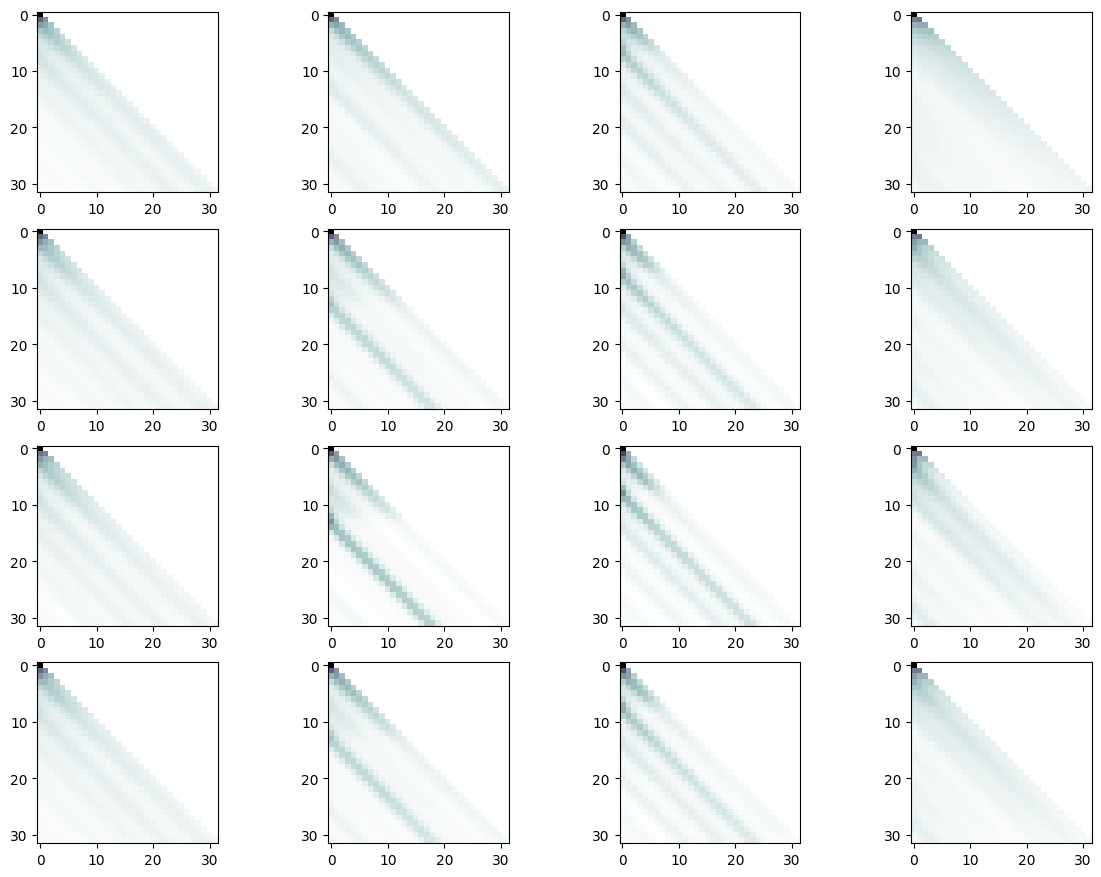

array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.50336832, 0.49663168, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.38536359, 0.30938741, 0.305249  , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.06294965, 0.06867507, 0.05597842, ..., 0.02876056, 0.        ,
        0.        ],
       [0.04193985, 0.06035608, 0.06583305, ..., 0.02788139, 0.02751849,
        0.        ],
       [0.0263045 , 0.04085199, 0.05881289, ..., 0.0342803 , 0.02711166,
        0.02675927]])

In [139]:
ah = plot_attention(att, 0, 4, True)
ah.cpu().numpy()

In [140]:
def accuracy(prediction, target, error=0.01):
    prediction, target = prediction*divider, target*divider
    total = ((prediction >= target*(1-error)) & (prediction <= target*(1+error))) == True
    acc = (total.float().count_nonzero() / target.numel()).item()
    return np.round(acc, 4) * 100

In [141]:
accuracy(attention(eval_inp), eval_out)

0.0

In [142]:
def train(epochs: int, show=True, checkpoints=5):
    torch.cuda.empty_cache()
    attention.requires_gradients(True)
    # attention.causal_mask = False

    losses = []
    ts, ud, ut = clock.perf_counter(), 0, epochs
    best_loss = F.mse_loss(attention(train_inp), train_out)
    best_epoch = -1
    save_state = attention.state_dict()
    for epoch in range(epochs):
        try:
            optimizer.zero_grad()
            test_actv = attention(train_inp)
            loss = F.mse_loss(test_actv, train_out)
            loss.backward()
            optimizer.step()

            losses.append(loss.cpu().item())

            if epoch % checkpoints == 0 and loss < best_loss:
                best_loss = loss
                save_state = attention.state_dict()
                best_epoch = epoch

            ud += 1
            eta(ts, ud, ut, f"training | loss={loss.cpu().item(): .4e} | "
                            f"best={best_loss.cpu().item(): .4e} | "
                            f"epoch={best_epoch}")
        except KeyboardInterrupt:
            break

    attention.load_state_dict(save_state)

    # attention.causal_mask = True
    if show:
        plt.plot(np.log10(losses))
        plt.title(f"Loss")

    attention.requires_gradients(False)
    torch.cuda.empty_cache()
    return losses

training | loss= 9.5461e-06 | best= 9.5465e-06 | epoch=29995: progress=100% eta=0sec

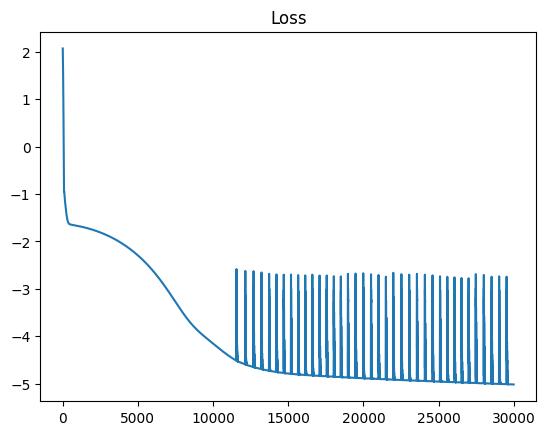

In [143]:
train(30000);

In [144]:
accuracy(attention(eval_inp), eval_out), accuracy(attention(train_inp), train_out)

(83.5, 82.84)

In [145]:
outputs, (att, att_val) = attention(eval_inp, verbose=True, get=True)
att.max(), att.min()


Executing Self Attention
Post Linearization =>

Query =>
tensor([[[[-0.1526,  0.5097,  2.4124,  ...,  2.4546,  0.4628, -0.2363],
          [-0.1517,  0.5103,  2.4167,  ...,  2.4535,  0.4617, -0.2370],
          [-0.1507,  0.5110,  2.4210,  ...,  2.4524,  0.4605, -0.2376],
          ...,
          [-0.1250,  0.5274,  2.5380,  ...,  2.4222,  0.4298, -0.2554],
          [-0.1241,  0.5280,  2.5423,  ...,  2.4211,  0.4287, -0.2560],
          [-0.1231,  0.5286,  2.5466,  ...,  2.4200,  0.4275, -0.2567]],

         [[ 0.5709,  0.9727,  5.7087,  ...,  1.6046, -0.4035, -0.7362],
          [ 0.5719,  0.9733,  5.7131,  ...,  1.6035, -0.4047, -0.7368],
          [ 0.5728,  0.9739,  5.7174,  ...,  1.6024, -0.4058, -0.7375],
          ...,
          [ 0.5985,  0.9903,  5.8344,  ...,  1.5722, -0.4365, -0.7552],
          [ 0.5995,  0.9909,  5.8387,  ...,  1.5711, -0.4377, -0.7559],
          [ 0.6004,  0.9915,  5.8430,  ...,  1.5700, -0.4388, -0.7565]],

         [[ 0.2819,  0.7878,  4.3919,  ..., 

(tensor(1., device='cuda:0', dtype=torch.float64),
 tensor(0., device='cuda:0', dtype=torch.float64))

In [146]:
for i, att_head in enumerate(eval_out[0, :6]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

Record 1: torch.Size([1, 32])
tensor([[201., 202., 203.,  ..., 230., 231., 232.]], device='cuda:0',
       dtype=torch.float64)
Record 2: torch.Size([1, 32])
tensor([[962., 963., 964.,  ..., 991., 992., 993.]], device='cuda:0',
       dtype=torch.float64)
Record 3: torch.Size([1, 32])
tensor([[658., 659., 660.,  ..., 687., 688., 689.]], device='cuda:0',
       dtype=torch.float64)
Record 4: torch.Size([1, 32])
tensor([[633., 634., 635.,  ..., 662., 663., 664.]], device='cuda:0',
       dtype=torch.float64)
Record 5: torch.Size([1, 32])
tensor([[281., 282., 283.,  ..., 310., 311., 312.]], device='cuda:0',
       dtype=torch.float64)
Record 6: torch.Size([1, 32])
tensor([[109., 110., 111.,  ..., 138., 139., 140.]], device='cuda:0',
       dtype=torch.float64)


In [147]:
for i, att_head in enumerate(outputs[0, :6]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

Record 1: torch.Size([1, 32])
tensor([[193., 194., 195.,  ..., 231., 232., 232.]], device='cuda:0',
       dtype=torch.float64)
Record 2: torch.Size([1, 32])
tensor([[963., 963., 962.,  ..., 985., 988., 992.]], device='cuda:0',
       dtype=torch.float64)
Record 3: torch.Size([1, 32])
tensor([[667., 667., 667.,  ..., 687., 689., 692.]], device='cuda:0',
       dtype=torch.float64)
Record 4: torch.Size([1, 32])
tensor([[642., 642., 642.,  ..., 662., 663., 666.]], device='cuda:0',
       dtype=torch.float64)
Record 5: torch.Size([1, 32])
tensor([[273., 274., 275.,  ..., 310., 311., 313.]], device='cuda:0',
       dtype=torch.float64)
Record 6: torch.Size([1, 32])
tensor([[106., 107., 108.,  ..., 139., 140., 138.]], device='cuda:0',
       dtype=torch.float64)


In [148]:
for i, att_head in enumerate(eval_inp[0, :6]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

Record 1: torch.Size([1, 32])
tensor([[200., 201., 202.,  ..., 229., 230., 231.]], device='cuda:0',
       dtype=torch.float64)
Record 2: torch.Size([1, 32])
tensor([[961., 962., 963.,  ..., 990., 991., 992.]], device='cuda:0',
       dtype=torch.float64)
Record 3: torch.Size([1, 32])
tensor([[657., 658., 659.,  ..., 686., 687., 688.]], device='cuda:0',
       dtype=torch.float64)
Record 4: torch.Size([1, 32])
tensor([[632., 633., 634.,  ..., 661., 662., 663.]], device='cuda:0',
       dtype=torch.float64)
Record 5: torch.Size([1, 32])
tensor([[280., 281., 282.,  ..., 309., 310., 311.]], device='cuda:0',
       dtype=torch.float64)
Record 6: torch.Size([1, 32])
tensor([[108., 109., 110.,  ..., 137., 138., 139.]], device='cuda:0',
       dtype=torch.float64)


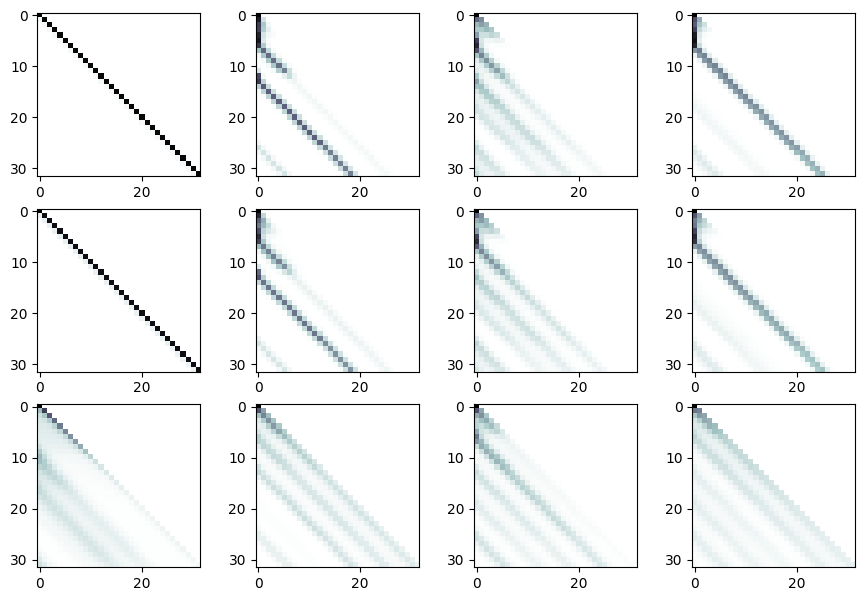

tensor([[1.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.5227, 0.4773, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.2424, 0.3961, 0.3615,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0105, 0.0173, 0.0411,  ..., 0.0622, 0.0000, 0.0000],
        [0.0119, 0.0104, 0.0171,  ..., 0.0684, 0.0612, 0.0000],
        [0.0176, 0.0117, 0.0102,  ..., 0.0422, 0.0670, 0.0599]],
       device='cuda:0', dtype=torch.float64)

In [149]:
plot_attention(att, 0, 3, True, size=(1080, 720))

tensor([[ 0,  1,  2,  ...,  7,  8,  9],
        [10, 11, 12,  ..., 17, 18, 19],
        [20, 21, 22,  ..., 27, 28, 29],
        ...,
        [70, 71, 72,  ..., 77, 78, 79],
        [80, 81, 82,  ..., 87, 88, 89],
        [90, 91, 92,  ..., 97, 98, 99]])

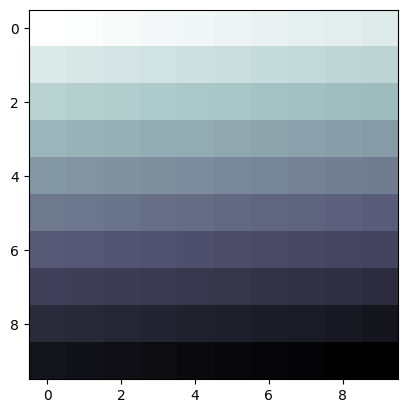

In [150]:
plt.imshow(torch.arange(10*10).view(10, 10), cmap='bone_r')
torch.arange(10*10).view(10, 10)